# CVAE Student-t para generar escenarios BTC–ETH

Este notebook implementa **únicamente el mejor CVAE encontrado** para nuestro
dataset. La búsqueda de arquitectura e hiperparámetros ya se realizó y se
resume en la sección 3; no se repite aquí para mantener un recorrido didáctico:

1. cargamos el split temporal sin fugas;
2. entendemos por qué esta configuración fue seleccionada;
3. construimos el encoder, el espacio latente y el decoder Student-t;
4. entrenamos una sola vez el modelo definitivo;
5. generamos escenarios y comprobamos su calidad en test;
6. guardamos encoder, decoder, métricas y escenarios.

El objetivo no es predecir una única trayectoria futura. Queremos aprender una
**distribución condicional** de posibles retornos BTC–ETH durante los próximos
30 días, dado el estado de mercado observado durante los 60 días anteriores.

In [1]:
from __future__ import annotations

from dataclasses import asdict, dataclass
from pathlib import Path
import json
import math
import sys
import time
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import wasserstein_distance
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

tf.config.experimental.enable_op_determinism()
warnings.filterwarnings("ignore", category=UserWarning, module="keras")
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 180)

ROOT = Path.cwd()
if not (ROOT / "data").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))

DATASET_PATH = ROOT / "data/normalized/binance/btc_eth_6h_c240_t120_train_normalized.npz"
SPLIT_PATH = ROOT / "data/splits/binance/btc_eth_6h_c240_t120_purged_split.npz"
OUTPUT_DIR = ROOT / "outputs/cvae_best"

BATCH_SIZE = 128
MAX_EPOCHS = 60
PATIENCE = 10
SEED = 42
SCENARIOS_PER_CONDITION = 4

keras.utils.set_random_seed(SEED)

print("TensorFlow:", tf.__version__)
print("Dispositivos:", tf.config.list_physical_devices())
print("Raíz del proyecto:", ROOT)

TensorFlow: 2.21.0
Dispositivos: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]
Raíz del proyecto: /Users/jchulvi/projects/Taller_Generativos


## 1. Dataset y split temporal

Cada muestra tiene dos elementos:

- `condition_features`: 14 variables normalizadas que resumen los 60 días
  anteriores —retorno acumulado, volatilidad, drawdown, volumen, rango,
  correlación BTC–ETH y régimen de tendencia—;
- `target_returns`: 120 retornos de seis horas para BTC y ETH, equivalentes a
  los 30 días futuros que queremos modelar.

Usamos el split temporal congelado del proyecto. Entrenamiento, validación y
test están separados por purgas de 90 días, por lo que ninguna ventana comparte
timestamps entre bloques. La normalización fue ajustada solo con train.

In [2]:
with np.load(DATASET_PATH, allow_pickle=False) as data:
    conditions = data["condition_features"].astype(np.float32)
    targets = data["target_returns"].astype(np.float32)
    feature_names = data["feature_names"].copy()
    assets = data["assets"].copy()
    return_mean = data["return_mean"].astype(np.float32)
    return_scale = data["return_scale"].astype(np.float32)

with np.load(SPLIT_PATH, allow_pickle=False) as split:
    train_ids = split["train_sample_ids"].copy()
    validation_ids = split["validation_sample_ids"].copy()
    test_ids = split["test_sample_ids"].copy()

x_train, c_train = targets[train_ids], conditions[train_ids]
x_validation, c_validation = targets[validation_ids], conditions[validation_ids]
x_test, c_test = targets[test_ids], conditions[test_ids]

dataset_summary = pd.DataFrame(
    {
        "bloque": ["train", "validación", "test"],
        "muestras": [len(x_train), len(x_validation), len(x_test)],
        "objetivo": [str(x_train.shape[1:]), str(x_validation.shape[1:]), str(x_test.shape[1:])],
        "condición": [str(c_train.shape[1:]), str(c_validation.shape[1:]), str(c_test.shape[1:])],
    }
)
dataset_summary

,bloque,muestras,objetivo,condición
0,train,4710,"(120, 2)","(14,)"
1,validación,1832,"(120, 2)","(14,)"
2,test,1826,"(120, 2)","(14,)"


Las 9.096 ventanas se desplazan una vela cada vez y se solapan mucho. Por eso
son suficientes para entrenar y comparar modelos, pero no equivalen a 9.096
historias independientes. En test conservamos también un control de 16 anclas
separadas por 120 velas para no exagerar la evidencia estadística.

In [3]:
def make_dataset(x, c, *, shuffle, seed=SEED):
    dataset = tf.data.Dataset.from_tensor_slices(
        {"trajectory": x, "condition": c}
    )
    if shuffle:
        dataset = dataset.shuffle(len(x), seed=seed, reshuffle_each_iteration=True)
    return dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)


train_dataset = make_dataset(x_train, c_train, shuffle=True)
validation_dataset = make_dataset(x_validation, c_validation, shuffle=False)

print("Barajado reproducible y operaciones TensorFlow deterministas: activados")

Barajado reproducible y operaciones TensorFlow deterministas: activados


## 2. Configuración definitiva

Toda la configuración del modelo está reunida aquí. No hay un espacio de
búsqueda oculto ni parámetros que cambien entre celdas.

In [4]:
@dataclass(frozen=True)
class CVAEConfig:
    name: str = "student_medium_l8_b01"
    filters: tuple[int, int] = (32, 64)
    dense_units: int = 96
    condition_units: tuple[int, int] = (24, 48)
    latent_dim: int = 8
    beta: float = 0.01
    free_bits: float = 0.02
    warmup_epochs: int = 10
    student_df: float = 5.0


CONFIG = CVAEConfig()
pd.Series(asdict(CONFIG), name="valor").to_frame()

,valor
name,student_medium_l8_b01
filters,"(32, 64)"
dense_units,96
condition_units,"(24, 48)"
latent_dim,8
beta,0.01
free_bits,0.02
warmup_epochs,10
student_df,5.0


## 3. Qué búsqueda hicimos y por qué ganó este modelo

Antes de simplificar el notebook se ejecutó un benchmark determinista de **39
configuraciones**. Todas usaron exactamente el mismo train, validación, semilla
inicial y métricas. La selección no se basó solo en la reconstrucción: el score
combinó media, volatilidad, cuantiles, correlación BTC–ETH, autocorrelación de
magnitud, retorno acumulado, drawdown y calibración por regímenes.

### Familias comparadas

| Decisión | Opciones comprobadas | Resultado |
|---|---|---|
| Distribución de salida | MSE, Gaussiana bivariante, Student-t bivariante | Student-t fue claramente superior por sus colas gruesas |
| Capacidad | filtros `(16,32)`, `(32,64)`, `(48,96)`; densas 64–128 | la capacidad media generalizó mejor |
| Espacio latente | 4, 8, 12 y 16 dimensiones | 8 fue el mejor compromiso entre diversidad y estabilidad |
| Regularización | varios `beta` entre 0.001 y 0.03; *free bits* 0–0.05 | `beta=0.01`, `free_bits=0.02` mantuvo el KL activo sin dominar la NLL |
| Condición | 14 resúmenes, historia Conv1D, historia GRU y modos híbridos | el resumen fue más estable; la historia completa añadió capacidad, pero no señal útil suficiente |
| Colas | Student-t con 3, 4, 5, 7 y 10 grados de libertad | 5 equilibró centro y extremos |
| Trayectoria | pérdida auxiliar acumulada con pesos 0.01–0.30 | no mejoró el equilibrio global de forma estable |

Los scores de una sola semilla no eran suficientes. Reentrenamos los tres
mejores candidatos con semillas 7, 42 y 123 y calculamos
`score robusto = media + desviación típica`. Así penalizamos una arquitectura
que solo funciona con una inicialización afortunada.

| Candidato finalista | Condición | Score medio | Desv. | Score robusto |
|---|---:|---:|---:|---:|
| **`student_medium_l8_b01`** | resumen | **0.1241** | **0.0173** | **0.1414** |
| `student_hconv_l4` | híbrida Conv1D | 0.1295 | 0.0253 | 0.1547 |
| `student_medium_l16_df5` | resumen | 0.1391 | 0.0460 | 0.1851 |

Por familias, el mejor score de la ronda inicial fue aproximadamente 0.106
para Student-t, 0.209 para Gaussiana y 0.911 para MSE. MSE generaba la media de
muchas trayectorias posibles y sufría **subdispersión**; la Gaussiana mejoró la
volatilidad, pero infrarrepresentó las colas. Student-t resolvió ambos problemas
sin separar BTC y ETH.

La API de Binance también se auditó antes del benchmark. Solo había 18 velas de
seis horas nuevas por activo: ampliaban ligeramente test, pero no train ni el
número de regímenes. Por ello mantuvimos el snapshot congelado y comparable.

## 4. Cómo funciona el CVAE ganador

### 4.1 Qué distribución aprende

Llamamos `x` a la trayectoria futura `(120, 2)` y `c` al estado de mercado
`(14,)`. El objetivo es aproximar:

\[
p_\theta(x\mid c)=\int p_\theta(x\mid z,c)\,p(z)\,dz,
\qquad p(z)=\mathcal N(0,I).
\]

`z` representa factores futuros que no están determinados por la condición:
intensidad del movimiento, dirección, shocks o combinaciones de ellos. Para
generar escenarios nuevos muestreamos distintos `z` manteniendo fija `c`.

Durante entrenamiento desconocemos qué `z` explica cada trayectoria real. El
encoder aprende una aproximación posterior:

\[
q_\phi(z\mid x,c)=\mathcal N(\mu_\phi(x,c),
\operatorname{diag}(\sigma_\phi^2(x,c))).
\]

El decoder aprende `p_theta(x | z,c)`. La condición aparece en ambos lados: en
el encoder ayuda a separar lo ya conocido de lo incierto; en el decoder hace
que una misma zona latente produzca resultados diferentes según el mercado.

### 4.2 Encoder

Las dos Conv1D recorren el eje temporal, no el eje de activos:

```text
trayectoria (120, 2)
  -> Conv1D(32, kernel=5, stride=2)  -> (60, 32)
  -> Conv1D(64, kernel=5, stride=2)  -> (30, 64)
  -> Flatten                         -> 1920

condición (14) -> Dense(24) -> Dense(48)

concat(1920, 48) -> Dense(96)
                 -> z_mean (8)
                 -> z_log_var (8)
```

La media y el logaritmo de la varianza parametrizan el posterior. No hacemos
que el encoder emita un punto fijo, porque necesitamos que el latente conserve
incertidumbre.

### 4.3 Truco de reparametrización

Muestrear directamente de una distribución impediría propagar gradientes. Lo
reescribimos como una transformación diferenciable:

\[
\epsilon\sim\mathcal N(0,I),\qquad
z=\mu+\exp(\tfrac12\log\sigma^2)\odot\epsilon.
\]

La aleatoriedad queda en `epsilon`; los parámetros `mu` y `log_var` continúan
dentro del grafo de TensorFlow.

In [5]:
@keras.utils.register_keras_serializable(package="crypto_generative")
class Sampling(layers.Layer):
    """Aplica z = media + desviación * epsilon."""

    def call(self, inputs):
        z_mean, z_log_var = inputs
        epsilon = keras.random.normal(shape=tf.shape(z_mean))
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon


def encode_condition(condition_input, prefix):
    """Proyecta las 14 variables a una representación compacta."""
    x = layers.Dense(
        CONFIG.condition_units[0], activation="swish", name=f"{prefix}_condition_24"
    )(condition_input)
    return layers.Dense(
        CONFIG.condition_units[1], activation="swish", name=f"{prefix}_condition_48"
    )(x)


def build_encoder_decoder(trajectory_shape=(120, 2), condition_dim=14):
    steps, n_assets = trajectory_shape

    trajectory_input = keras.Input(shape=trajectory_shape, name="trajectory")
    condition_input = keras.Input(shape=(condition_dim,), name="condition")
    x = trajectory_input
    for index, filters in enumerate(CONFIG.filters, start=1):
        x = layers.Conv1D(
            filters, 5, strides=2, padding="same", activation="swish",
            name=f"encoder_conv_{index}",
        )(x)
    x = layers.Flatten(name="encoder_flatten")(x)
    encoded_condition = encode_condition(condition_input, "encoder")
    x = layers.Concatenate(name="encoder_concat")([x, encoded_condition])
    x = layers.Dense(CONFIG.dense_units, activation="swish", name="encoder_dense")(x)
    z_mean = layers.Dense(CONFIG.latent_dim, name="z_mean")(x)
    z_log_var = layers.Dense(CONFIG.latent_dim, name="z_log_var")(x)
    z = Sampling(name="z")([z_mean, z_log_var])
    encoder = keras.Model(
        {"trajectory": trajectory_input, "condition": condition_input},
        [z_mean, z_log_var, z],
        name="cvae_encoder",
    )

    latent_input = keras.Input(shape=(CONFIG.latent_dim,), name="latent")
    decoder_condition = keras.Input(shape=(condition_dim,), name="condition")
    decoded_condition = encode_condition(decoder_condition, "decoder")
    x = layers.Concatenate(name="decoder_concat")([latent_input, decoded_condition])
    x = layers.Dense(
        (steps // 4) * CONFIG.filters[-1], activation="swish", name="decoder_dense"
    )(x)
    x = layers.Reshape((steps // 4, CONFIG.filters[-1]), name="decoder_reshape")(x)
    for index, filters in enumerate(reversed(CONFIG.filters), start=1):
        x = layers.UpSampling1D(2, name=f"decoder_upsampling_{index}")(x)
        x = layers.Conv1D(
            filters, 5, padding="same", activation="swish",
            name=f"decoder_conv_{index}",
        )(x)
    raw_output = layers.Conv1D(
        2 * n_assets + 1, 5, padding="same", name="decoder_output"
    )(x)
    decoder = keras.Model(
        {"latent": latent_input, "condition": decoder_condition},
        raw_output,
        name="cvae_decoder",
    )
    return encoder, decoder


encoder, decoder = build_encoder_decoder(
    trajectory_shape=x_train.shape[1:], condition_dim=c_train.shape[1]
)
print("Parámetros encoder:", f"{encoder.count_params():,}")
print("Parámetros decoder:", f"{decoder.count_params():,}")

Parámetros encoder: 202,792
Parámetros decoder: 142,621


### 4.4 Decoder Student-t bivariante

El decoder expande `z` y `c` hasta recuperar 120 pasos. En cada paso no devuelve
un retorno fijo, sino cinco parámetros:

```text
[loc_BTC, loc_ETH, raw_scale_BTC, raw_scale_ETH, raw_rho]
```

Convertimos `raw_scale` con `softplus` para garantizar escalas positivas y
`raw_rho` con `0.95*tanh` para garantizar una matriz de correlación válida. La
salida define una Student-t bivariante con 5 grados de libertad. Frente a una
Gaussiana, asigna más probabilidad a movimientos extremos; frente a dos
distribuciones independientes, conserva la dependencia contemporánea BTC–ETH.

Para residuos estandarizados `u_BTC` y `u_ETH`, la distancia de Mahalanobis es:

\[
d^2=\frac{u_{BTC}^2-2\rho u_{BTC}u_{ETH}+u_{ETH}^2}{1-\rho^2}.
\]

La reconstrucción es la NLL Student-t media. Minimizarla obliga al modelo a
aprender simultáneamente localización, volatilidad, colas y correlación.

### 4.5 KL, beta y free bits

La pérdida total es:

\[
\mathcal L=\operatorname{NLL}_{Student-t}(x;\theta(z,c))
+\beta\,D_{KL}(q_\phi(z\mid x,c)\Vert\mathcal N(0,I)).
\]

- La NLL enseña calidad de reconstrucción probabilística.
- La KL acerca el posterior al prior normal que usaremos al generar.
- `beta=0.01` evita que la KL destruya demasiado pronto la información futura.
- El *warm-up* aumenta beta gradualmente durante 10 épocas.
- `free_bits=0.02` deja un pequeño presupuesto informativo por dimensión antes
  de penalizarla; así reducimos el riesgo de *posterior collapse*.

Si la KL cayese prácticamente a cero y las muestras fueran casi iguales,
sospecharíamos colapso. En el modelo final la KL permanece alrededor de 3–4,
señal de que el decoder utiliza el latente.

In [6]:
class ConditionalVAE(keras.Model):
    """CVAE con likelihood Student-t bivariante y KL regularizada."""

    def __init__(self, encoder, decoder):
        super().__init__(name=f"cvae_{CONFIG.name}")
        self.encoder = encoder
        self.decoder = decoder
        self.beta_weight = tf.Variable(0.0, trainable=False, dtype=tf.float32)
        self.total_loss_tracker = keras.metrics.Mean(name="total_loss")
        self.reconstruction_loss_tracker = keras.metrics.Mean(name="reconstruction_loss")
        self.raw_kl_loss_tracker = keras.metrics.Mean(name="raw_kl_loss")
        self.regularized_kl_loss_tracker = keras.metrics.Mean(name="regularized_kl_loss")

    @property
    def metrics(self):
        return [
            self.total_loss_tracker,
            self.reconstruction_loss_tracker,
            self.raw_kl_loss_tracker,
            self.regularized_kl_loss_tracker,
        ]

    @staticmethod
    def split_decoder_output(raw_output):
        location = raw_output[..., :2]
        scale = tf.nn.softplus(raw_output[..., 2:4]) + 1e-3
        rho = 0.95 * tf.nn.tanh(raw_output[..., 4])
        return location, scale, rho

    def reconstruction_loss(self, trajectory, raw_output):
        location, scale, rho = self.split_decoder_output(raw_output)
        standardized = (trajectory - location) / scale
        btc, eth = standardized[..., 0], standardized[..., 1]
        one_minus_rho_sq = tf.maximum(1.0 - tf.square(rho), 1e-4)
        mahalanobis = (
            tf.square(btc) - 2.0 * rho * btc * eth + tf.square(eth)
        ) / one_minus_rho_sq
        half_log_determinant = (
            tf.math.log(scale[..., 0])
            + tf.math.log(scale[..., 1])
            + 0.5 * tf.math.log(one_minus_rho_sq)
        )
        df = tf.cast(CONFIG.student_df, tf.float32)
        dimensions = tf.constant(2.0, dtype=tf.float32)
        constant = (
            tf.math.lgamma(df / 2.0)
            + 0.5 * dimensions * tf.math.log(df * math.pi)
            - tf.math.lgamma((df + dimensions) / 2.0)
        )
        element_loss = (
            constant
            + half_log_determinant
            + 0.5 * (df + dimensions) * tf.math.log1p(mahalanobis / df)
        )
        return tf.reduce_mean(element_loss)

    def calculate_losses(self, trajectory, condition, training):
        z_mean, z_log_var, sampled_z = self.encoder(
            {"trajectory": trajectory, "condition": condition}, training=training
        )
        z = sampled_z if training else z_mean
        raw_output = self.decoder(
            {"latent": z, "condition": condition}, training=training
        )
        reconstruction = self.reconstruction_loss(trajectory, raw_output)
        kl_per_dimension = -0.5 * (
            1.0 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var)
        )
        mean_kl_per_dimension = tf.reduce_mean(kl_per_dimension, axis=0)
        raw_kl = tf.reduce_sum(mean_kl_per_dimension)
        regularized_kl = tf.reduce_sum(
            tf.maximum(mean_kl_per_dimension, CONFIG.free_bits)
        )
        total = reconstruction + self.beta_weight * regularized_kl
        return total, reconstruction, raw_kl, regularized_kl

    def train_step(self, data):
        inputs = data[0] if isinstance(data, tuple) else data
        with tf.GradientTape() as tape:
            losses = self.calculate_losses(
                inputs["trajectory"], inputs["condition"], training=True
            )
        gradients = tape.gradient(losses[0], self.trainable_weights)
        self.optimizer.apply_gradients(zip(gradients, self.trainable_weights))
        return self.update_trackers(*losses)

    def test_step(self, data):
        inputs = data[0] if isinstance(data, tuple) else data
        losses = self.calculate_losses(
            inputs["trajectory"], inputs["condition"], training=False
        )
        return self.update_trackers(*losses)

    def update_trackers(self, total, reconstruction, raw_kl, regularized_kl):
        for tracker, value in zip(self.metrics, (total, reconstruction, raw_kl, regularized_kl)):
            tracker.update_state(value)
        return {metric.name: metric.result() for metric in self.metrics}


class BetaWarmup(keras.callbacks.Callback):
    """Aumenta beta linealmente hasta CONFIG.beta."""

    def on_epoch_begin(self, epoch, logs=None):
        fraction = min(1.0, (epoch + 1) / CONFIG.warmup_epochs)
        self.model.beta_weight.assign(CONFIG.beta * fraction)


model = ConditionalVAE(encoder, decoder)
model.compile(optimizer=keras.optimizers.Adam(1e-3))

## 5. Entrenamiento del único modelo

Entrenamos con `train` y usamos validación únicamente para *early stopping*.
Restauramos los pesos de la mejor época según `val_total_loss`. El test no
participa en ninguna decisión de entrenamiento.

In [7]:
keras.utils.set_random_seed(SEED)
callbacks = [
    BetaWarmup(),
    keras.callbacks.EarlyStopping(
        monitor="val_total_loss",
        patience=PATIENCE,
        mode="min",
        restore_best_weights=True,
    ),
    keras.callbacks.TerminateOnNaN(),
]

started = time.perf_counter()
history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=MAX_EPOCHS,
    callbacks=callbacks,
    verbose=0,
)
elapsed = time.perf_counter() - started

print(f"Épocas completadas: {len(history.epoch)}")
print(f"Tiempo: {elapsed:.1f} s")
print(f"KL final de validación: {history.history['val_raw_kl_loss'][-1]:.4f}")

Épocas completadas: 18
Tiempo: 13.5 s
KL final de validación: 4.1646


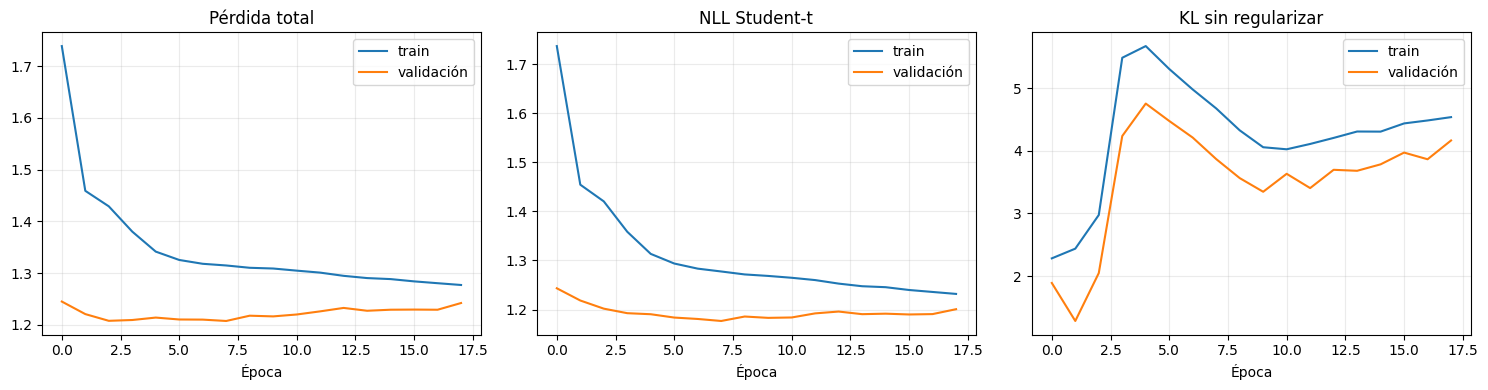

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for axis, metric, title in zip(
    axes,
    ("total_loss", "reconstruction_loss", "raw_kl_loss"),
    ("Pérdida total", "NLL Student-t", "KL sin regularizar"),
):
    axis.plot(history.history[metric], label="train")
    axis.plot(history.history[f"val_{metric}"], label="validación")
    axis.set_title(title)
    axis.set_xlabel("Época")
    axis.grid(alpha=0.25)
    axis.legend()
plt.tight_layout()
plt.show()

## 6. Generación de escenarios

Para generar no usamos el encoder: muestreamos `z ~ N(0,I)` y pasamos `z` y
la condición al decoder. Después muestreamos una Student-t bivariante con los
parámetros predichos. El mismo denominador chi-cuadrado para BTC y ETH conserva
la dependencia de cola conjunta.

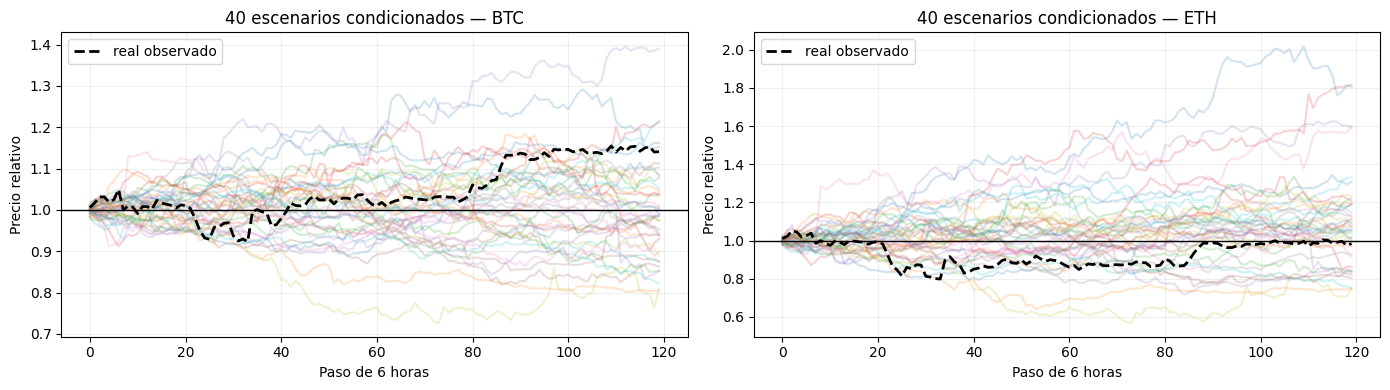

In [9]:
def parse_decoder_output(raw_output):
    location = raw_output[..., :2]
    raw_scale = raw_output[..., 2:4]
    scale = np.log1p(np.exp(-np.abs(raw_scale))) + np.maximum(raw_scale, 0) + 1e-3
    rho = 0.95 * np.tanh(raw_output[..., 4])
    return location, scale, rho


def sample_decoder(decoder, condition_batch, seed):
    rng = np.random.default_rng(seed)
    latent = rng.normal(size=(len(condition_batch), CONFIG.latent_dim)).astype(np.float32)
    raw_output = np.asarray(
        decoder({"latent": latent, "condition": condition_batch}, training=False)
    )
    location, scale, rho = parse_decoder_output(raw_output)
    independent = rng.normal(size=location.shape)
    correlated = np.empty_like(independent)
    correlated[..., 0] = independent[..., 0]
    correlated[..., 1] = (
        rho * independent[..., 0]
        + np.sqrt(np.maximum(1.0 - np.square(rho), 1e-6)) * independent[..., 1]
    )
    chi_square = rng.chisquare(CONFIG.student_df, size=location.shape[:-1] + (1,))
    student_noise = correlated / np.sqrt(chi_square / CONFIG.student_df)
    return (location + scale * student_noise).astype(np.float32)


example_condition = np.repeat(c_test[:1], 40, axis=0)
example_generated = sample_decoder(decoder, example_condition, seed=20_260_807)
example_returns = example_generated * return_scale[None, None, :] + return_mean[None, None, :]
real_example_returns = x_test[0] * return_scale[None, :] + return_mean[None, :]
generated_prices = np.exp(np.cumsum(example_returns, axis=1))
real_price = np.exp(np.cumsum(real_example_returns, axis=0))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for asset_index, (axis, asset) in enumerate(zip(axes, assets)):
    axis.plot(generated_prices[:, :, asset_index].T, alpha=0.2)
    axis.plot(real_price[:, asset_index], "k--", linewidth=2, label="real observado")
    axis.axhline(1.0, color="black", linewidth=1)
    axis.set_title(f"40 escenarios condicionados — {asset}")
    axis.set_xlabel("Paso de 6 horas")
    axis.set_ylabel("Precio relativo")
    axis.grid(alpha=0.2)
    axis.legend()
plt.tight_layout()
plt.show()

## 7. Métricas generativas en test

Una buena NLL no garantiza buenas simulaciones. Comparamos distribución
marginal, colas, correlación BTC–ETH, clustering de volatilidad, retorno
acumulado, drawdown y calibración en cuatro regímenes de volatilidad previa.
Todas las métricas son errores: **menor es mejor**.

In [10]:
def lag_one_correlation(values, transform):
    transformed = transform(values)
    correlations = []
    for asset_index in range(transformed.shape[-1]):
        left = transformed[:, :-1, asset_index].ravel()
        right = transformed[:, 1:, asset_index].ravel()
        correlations.append(float(np.corrcoef(left, right)[0, 1]))
    return np.asarray(correlations)


def maximum_drawdown(returns):
    prices = np.exp(np.cumsum(returns, axis=1))
    running_max = np.maximum.accumulate(
        np.concatenate([np.ones((len(prices), 1, prices.shape[-1])), prices], axis=1),
        axis=1,
    )[:, 1:, :]
    return np.min(prices / running_max - 1.0, axis=1)


def distribution_metrics(real, generated, scenarios_per_condition, condition_batch):
    eps = 1e-8
    real_std = real.std(axis=(0, 1))
    generated_std = generated.std(axis=(0, 1))
    mean_error = np.mean(np.abs(generated.mean((0, 1)) - real.mean((0, 1))) / (real_std + eps))
    log_std_error = np.mean(np.abs(np.log((generated_std + eps) / (real_std + eps))))
    quantiles = (0.01, 0.05, 0.5, 0.95, 0.99)
    quantile_error = np.mean(
        np.abs(np.quantile(generated, quantiles, axis=(0, 1)) - np.quantile(real, quantiles, axis=(0, 1)))
        / (real_std[None, :] + eps)
    )
    correlation_error = abs(
        np.corrcoef(real.reshape(-1, 2), rowvar=False)[0, 1]
        - np.corrcoef(generated.reshape(-1, 2), rowvar=False)[0, 1]
    )
    abs_acf_error = np.mean(np.abs(lag_one_correlation(generated, np.abs) - lag_one_correlation(real, np.abs)))
    squared_acf_error = np.mean(np.abs(lag_one_correlation(generated, np.square) - lag_one_correlation(real, np.square)))
    real_cumulative, generated_cumulative = real.sum(axis=1), generated.sum(axis=1)
    cumulative_wasserstein = np.mean([
        wasserstein_distance(real_cumulative[:, i], generated_cumulative[:, i])
        / (real_cumulative[:, i].std() + eps) for i in range(2)
    ])
    real_returns = real * return_scale[None, None, :] + return_mean[None, None, :]
    generated_returns = generated * return_scale[None, None, :] + return_mean[None, None, :]
    real_drawdown, generated_drawdown = maximum_drawdown(real_returns), maximum_drawdown(generated_returns)
    drawdown_wasserstein = np.mean([
        wasserstein_distance(real_drawdown[:, i], generated_drawdown[:, i])
        / (real_drawdown[:, i].std() + eps) for i in range(2)
    ])

    n_scenarios = scenarios_per_condition
    n_conditions = len(generated) // n_scenarios
    real_grouped = real.reshape(n_conditions, n_scenarios, *real.shape[1:])[:, 0]
    generated_grouped = generated.reshape(n_conditions, n_scenarios, *generated.shape[1:])
    condition_grouped = condition_batch.reshape(n_conditions, n_scenarios, -1)[:, 0]
    regime_score = condition_grouped[:, [1, 7]].mean(axis=1)
    regime_ids = np.digitize(regime_score, np.quantile(regime_score, [0.25, 0.5, 0.75]))
    real_cum_all = real_grouped.sum(axis=1)
    real_vol_all = real_grouped.std(axis=1)
    regime_errors = []
    for regime_id in range(4):
        mask = regime_ids == regime_id
        real_paths = real_grouped[mask]
        generated_paths = generated_grouped[mask].reshape(-1, *generated.shape[1:])
        for asset_index in range(2):
            regime_errors.extend([
                wasserstein_distance(real_paths[:, :, asset_index].sum(1), generated_paths[:, :, asset_index].sum(1))
                / (real_cum_all[:, asset_index].std() + eps),
                wasserstein_distance(real_paths[:, :, asset_index].std(1), generated_paths[:, :, asset_index].std(1))
                / (real_vol_all[:, asset_index].std() + eps),
            ])
    regime_calibration_error = float(np.mean(regime_errors))

    metrics = {
        "mean_error": float(mean_error),
        "log_std_error": float(log_std_error),
        "quantile_error": float(quantile_error),
        "correlation_error": float(correlation_error),
        "abs_acf_error": float(abs_acf_error),
        "squared_acf_error": float(squared_acf_error),
        "cumulative_wasserstein": float(cumulative_wasserstein),
        "drawdown_wasserstein": float(drawdown_wasserstein),
        "regime_calibration_error": regime_calibration_error,
        "generated_std_btc": float(generated_returns.std((0, 1))[0]),
        "generated_std_eth": float(generated_returns.std((0, 1))[1]),
        "real_std_btc": float(real_returns.std((0, 1))[0]),
        "real_std_eth": float(real_returns.std((0, 1))[1]),
    }
    metrics["selection_score"] = float(np.mean(list(metrics.values())[:9]))
    return metrics


test_conditions = np.repeat(c_test, SCENARIOS_PER_CONDITION, axis=0)
test_real = np.repeat(x_test, SCENARIOS_PER_CONDITION, axis=0)
test_generated = sample_decoder(decoder, test_conditions, seed=20_260_805)
test_metrics = distribution_metrics(
    test_real, test_generated, SCENARIOS_PER_CONDITION, test_conditions
)
pd.Series(test_metrics, name="valor").to_frame()

,valor
mean_error,0.027464
log_std_error,0.016434
quantile_error,0.108153
correlation_error,0.023897
abs_acf_error,0.012154
squared_acf_error,0.035352
cumulative_wasserstein,0.311010
drawdown_wasserstein,0.194116
regime_calibration_error,0.554399
generated_std_btc,0.010990


También repetimos el control con una ancla cada 120 velas. Solo quedan 16
objetivos no solapados, de modo que esta tabla es una comprobación de
sensibilidad, no una estimación precisa de eventos extremos.

In [11]:
non_overlapping_ids = np.arange(0, len(x_test), 120)
non_overlapping_conditions = np.repeat(c_test[non_overlapping_ids], 20, axis=0)
non_overlapping_real = np.repeat(x_test[non_overlapping_ids], 20, axis=0)
non_overlapping_generated = sample_decoder(
    decoder, non_overlapping_conditions, seed=20_260_806
)
non_overlapping_metrics = distribution_metrics(
    non_overlapping_real, non_overlapping_generated, 20, non_overlapping_conditions
)
print("Anclas no solapadas:", len(non_overlapping_ids))
pd.DataFrame({"test_deslizante": test_metrics, "test_no_solapado": non_overlapping_metrics})

Anclas no solapadas: 16


,test_deslizante,test_no_solapado
mean_error,0.027464,0.023230
log_std_error,0.016434,0.057681
quantile_error,0.108153,0.161070
correlation_error,0.023897,0.033839
abs_acf_error,0.012154,0.008163
squared_acf_error,0.035352,0.019884
cumulative_wasserstein,0.311010,0.324670
drawdown_wasserstein,0.194116,0.312641
regime_calibration_error,0.554399,0.707004
generated_std_btc,0.010990,0.010775


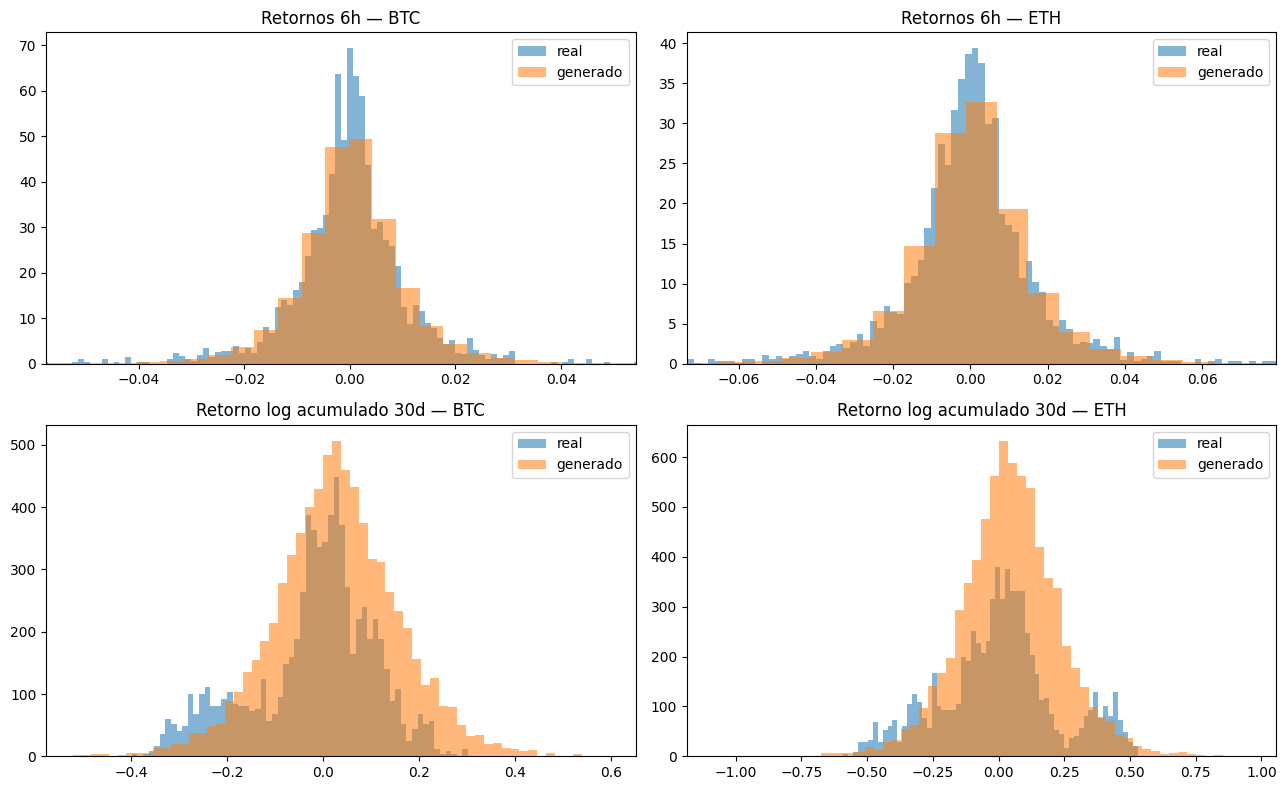

In [12]:
real_test_returns = test_real * return_scale[None, None, :] + return_mean[None, None, :]
generated_test_returns = test_generated * return_scale[None, None, :] + return_mean[None, None, :]

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
for asset_index, asset in enumerate(assets):
    axes[0, asset_index].hist(real_test_returns[:, :, asset_index].ravel(), bins=120, density=True, alpha=0.55, label="real")
    axes[0, asset_index].hist(generated_test_returns[:, :, asset_index].ravel(), bins=120, density=True, alpha=0.55, label="generado")
    axes[0, asset_index].set_title(f"Retornos 6h — {asset}")
    axes[0, asset_index].set_xlim(
        np.quantile(real_test_returns[:, :, asset_index], 0.001),
        np.quantile(real_test_returns[:, :, asset_index], 0.999),
    )
    axes[0, asset_index].legend()
    axes[1, asset_index].hist(real_test_returns[:, :, asset_index].sum(1), bins=60, alpha=0.55, label="real")
    axes[1, asset_index].hist(generated_test_returns[:, :, asset_index].sum(1), bins=60, alpha=0.55, label="generado")
    axes[1, asset_index].set_title(f"Retorno log acumulado 30d — {asset}")
    axes[1, asset_index].legend()
plt.tight_layout()
plt.show()

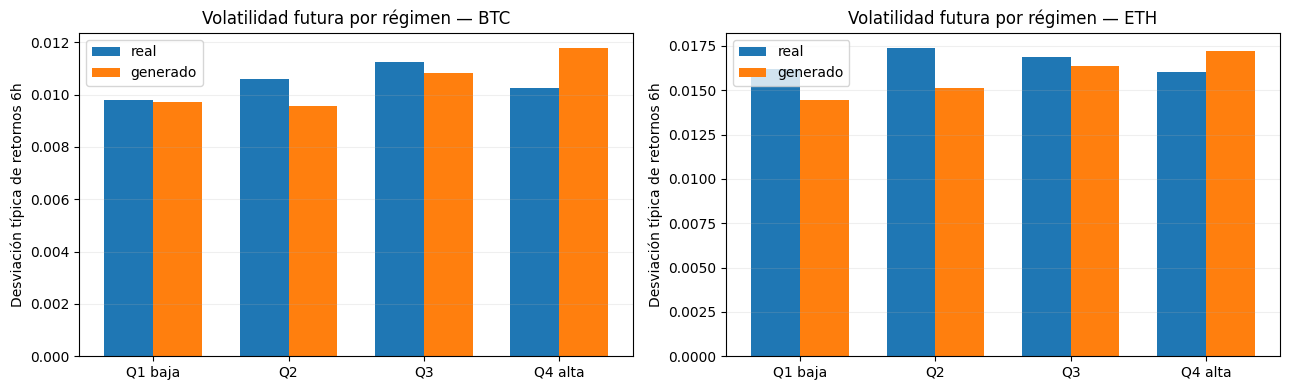

In [13]:
test_regime_score = c_test[:, [1, 7]].mean(axis=1)
regime_ids = np.digitize(test_regime_score, np.quantile(test_regime_score, [0.25, 0.5, 0.75]))
generated_grouped_returns = generated_test_returns.reshape(
    len(x_test), SCENARIOS_PER_CONDITION, *generated_test_returns.shape[1:]
)
real_unrepeated_returns = x_test * return_scale[None, None, :] + return_mean[None, None, :]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
labels = ["Q1 baja", "Q2", "Q3", "Q4 alta"]
positions = np.arange(4)
for asset_index, (axis, asset) in enumerate(zip(axes, assets)):
    real_vol, generated_vol = [], []
    for regime_id in range(4):
        mask = regime_ids == regime_id
        real_vol.append(real_unrepeated_returns[mask, :, asset_index].std(1).mean())
        generated_vol.append(generated_grouped_returns[mask, :, :, asset_index].std(2).mean())
    axis.bar(positions - 0.18, real_vol, 0.36, label="real")
    axis.bar(positions + 0.18, generated_vol, 0.36, label="generado")
    axis.set_xticks(positions, labels)
    axis.set_title(f"Volatilidad futura por régimen — {asset}")
    axis.set_ylabel("Desviación típica de retornos 6h")
    axis.grid(axis="y", alpha=0.2)
    axis.legend()
plt.tight_layout()
plt.show()

## 8. Guardado reproducible

In [14]:
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
encoder.save(OUTPUT_DIR / "encoder.keras")
decoder.save(OUTPUT_DIR / "decoder.keras")
np.savez_compressed(
    OUTPUT_DIR / "test_scenarios.npz",
    generated_normalized=test_generated,
    generated_returns=generated_test_returns,
    real_normalized=test_real,
    conditions=test_conditions,
    assets=assets,
)

metadata = {
    "selected_config": asdict(CONFIG),
    "selection_evidence": {
        "candidates_compared": 39,
        "stability_seeds": [7, 42, 123],
        "criterion": "mean_validation_score_plus_standard_deviation",
        "robust_validation_score": 0.141395,
    },
    "tensorflow_deterministic_ops": True,
    "epochs_completed": len(history.epoch),
    "train_samples": len(x_train),
    "validation_samples": len(x_validation),
    "test_samples": len(x_test),
    "test_metrics": test_metrics,
    "non_overlapping_test_metrics": non_overlapping_metrics,
}
(OUTPUT_DIR / "metadata.json").write_text(
    json.dumps(metadata, indent=2, ensure_ascii=False) + "\n", encoding="utf-8"
)
print("Artefactos guardados en:", OUTPUT_DIR)

Artefactos guardados en: /Users/jchulvi/projects/Taller_Generativos/outputs/cvae_best


## Conclusión

Hemos entrenado un único CVAE Student-t, seleccionado previamente entre 39
alternativas. El modelo conserva un KL activo, reproduce razonablemente la
volatilidad y la dependencia BTC–ETH, y genera trayectorias diversas para una
misma condición.

En esta ejecución el score conjunto de test es **0.1426**. La volatilidad
generada es 0.01099 para BTC y 0.01664 para ETH, muy próxima a 0.01091 y
0.01707 reales. El error de correlación es 0.0239. La distancia acumulada de
30 días (0.3110) es claramente más difícil que ajustar cada retorno de 6 horas.

La principal limitación continúa siendo el retorno acumulado a 30 días: las
distribuciones reales muestran regímenes y multimodalidad que el CVAE suaviza.
Además, solo disponemos de 16 anclas de test no solapadas. Por tanto, este es el
mejor CVAE comprobado para el taller y un buen generador exploratorio, pero no
debe presentarse todavía como simulador de riesgo extremo para producción.